In [1]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

**単変量統計**

In [ ]:
#単変量統計では、個々の特徴量ターゲットの間に統計的に顕著な関係があるかどうかを計算する
#そして、最も高い確信度で関連している特徴量が選択される

from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile


cancer = load_breast_cancer()

rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))

# ノイズを加える
X_w_noise = np.hstack([cancer.data, noise])

X_train, X_test, y_train, y_test = train_test_split(
    X_w_noise, cancer.target, random_state=0, test_size=.5)

# 単変量統計を使って、最も有用な特徴量を選択する
select = SelectPercentile(percentile=50)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)

print("X_train.shape: {}".format(X_train.shape))
print("X_train_selected.shape: {}".format(X_train_selected.shape))


X_train.shape: (284, 80)
X_train_selected.shape: (284, 40)


Text(0.5, 0, 'Sample index')

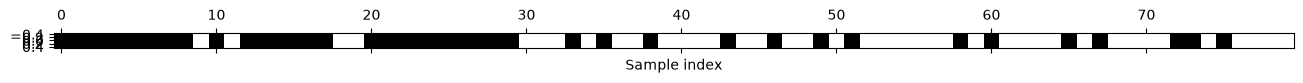

In [ ]:
#どの特徴量が選択されたかを確認する
mask = select.get_support()

#マスクを可視化する --黒が真、白が偽

#reshapeについて
#1 → 行数を 1行 にする
#-1 → 列数は NumPyに自動計算させる

plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")

In [ ]:
#ロジスティック回帰の性能を、全ての特徴量を使った場合と、選択された特徴量だけを使った場合で比較してみる

#ここではすべて使った場合の方がスコアが高くなったが、特徴量が多すぎてモデルを作ることができないような場合や、
#多くの特徴量が全く関係ないと思われるような場合には、単変量特徴量選択は有用

from sklearn.linear_model import LogisticRegression

#テストデータの変換
X_test_selected = select.transform(X_test)

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
print("Score with all features: {:.3f}".format(lr.score(X_test, y_test)))

lr.fit(X_train_selected, y_train)
print("Score with only selected features: {:.3f}".format(lr.score(X_test_selected, y_test)))


Score with all features: 0.951
Score with only selected features: 0.933


**モデルベース特徴量選択**

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

#medianを閾値として、重要度が高い特徴量だけを選択しているので、特徴量の数は半分になる
select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42), 
    threshold="median"
)

select.fit(X_train,y_train)
X_train_selected = select.transform(X_train)
X_test_selected = select.transform(X_test)

print("X_train shape:{}".format(X_train.shape))
print("X_train_selected shape:{}".format(X_train_selected.shape))

X_train shape:(284, 80)
X_train_selected shape:(284, 40)


Text(0.5, 0, 'Sample index')

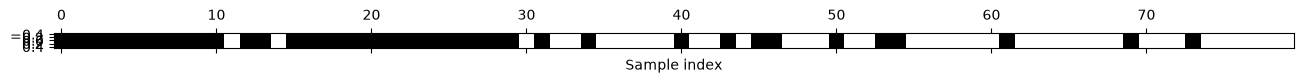

In [10]:
#選択された特徴量をみる
mask = select.get_support()

#マスクを可視化する --黒が真、白が偽
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")


In [15]:
from sklearn.linear_model import LogisticRegression

#性能を見てみる
score = LogisticRegression(max_iter=10000).fit(X_train_selected,y_train).score(X_test_selected,y_test)
print("Score with all features: {:.3f}".format(score))

Score with all features: 0.947


**反復特徴量選択**

Text(0.5, 0, 'Sample index')

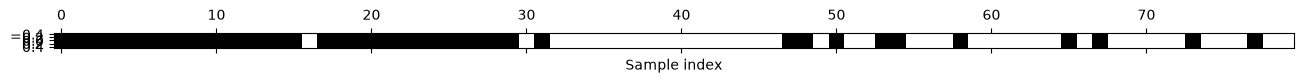

In [ ]:
# 再帰的意特徴量削減(RFE)
# モデルを繰り返し学習し、重要度の低い特徴量を順に削除して、指定した数の特徴量を残す

from sklearn.feature_selection import RFE

select = RFE(
    RandomForestClassifier(n_estimators=100, random_state=42), 
    n_features_to_select=40
)

select.fit(X_train,y_train)

mask = select.get_support()

#マスクを可視化する --黒が真、白が偽
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")


In [17]:
X_train_selected = select.transform(X_train)
X_test_selected = select.transform(X_test)

score = LogisticRegression(max_iter=10000).fit(X_train_selected,y_train).score(X_test_selected,y_test)
print("Score with all features: {:.3f}".format(score))

Score with all features: 0.940


In [18]:
#RFEの内部で用いられたモデルを用いて予測を行うこともできる
#これは、選択された特徴量だけを用いる

print("Score with all features: {:.3f}".format(select.score(X_test,y_test)))

Score with all features: 0.951
